# **Uloha 3 : Nejkratší cesta grafem**

.
Implementujte Dijkstra algoritmus pro nalezení nejkratší cesty mezi dvěma zadanými uzly grafu.
Vstupní data budou představována silniční sítí doplněnou vybranými sídly (alespoň 100 uzlů). S využitím přiloženého skriptu konvertujte podkladová data do grafové reprezentace.

Otestujte různé varianty volby ohodnocení w hran grafu tak, aby nalezená cesta měla:

nejkratší Eukleidovskou vzdálenost,

nejmenší transportní čas (2 varianty, bez/se zohledněním klikatosti komunikací).

Pro druhou variantu optimální cesty navrhněte také vhodnou metriku, která zohledňuje rozdílnou dobu jízdy na různých typech komunikací dle jejich návrhové rychlosti v a klikatosti κ, příkladem může být

t(u,v)=κ(l(u,v)/v(u,v)​).

Pro výpočet κ využijte poměr délky polyline l představující diskrétní křivku a vzdálenosti s koncových bodů polyline

κ=l(u,v) / s(u,v)​.

Každou z variant otestujte pro dvě dvě různé cesty tvořené alespoň 20 uzly. Výsledky umístěte do tabulky, vlastní cesty vizualizujte. Dosažené výsledky porovnejte s vybraným navigačním SW (alespoň 3).

# Dijsktra algoritmus


In [6]:
!pip install osmnx
!pip install geopy

In [7]:
import osmnx as ox
import pandas as pd
from collections import defaultdict
import geopy.distance
import builtins
import matplotlib.pyplot as plt
import networkx as nx
from queue import PriorityQueue
import random
import math

random.seed(10)
def loadEdges(file_name):
    # onvert list of lines to the graph
    PS = []
    PE = []
    W = []
    with open(file_name, "r") as f: #  added "r" for reading
        for line in f:
            parts = line.split()
            if len(parts) < 5: continue
            x1, y1, x2, y2, w = parts
            PS.append((float(x1), float(y1)))
            PE.append((float(x2), float(y2)))
            W.append(float(w))
    return PS, PE, W

# DATA PREPARATION (OSMnx)
place = "okres Znojmo, Czechia"

# Download road network
print(f"Downloading road network for: {place}...")
G = ox.graph_from_place(place, network_type="drive")

ox.settings.elevation_url_template = (
    "https://api.open-elevation.com/api/v1/lookup?locations={locations}"
)
# add elevation (meters) to each node
G = ox.elevation.add_node_elevations_google(
    G,
    batch_size=50,   # keep small to avoid 429 errors
    pause=1.0        # seconds between requests
)

# Download settlements (we want at least 100, using 'hamlet' and 'isolated_dwelling')
tags = {'place': ['city', 'town', 'village', 'hamlet', 'suburb', 'isolated_dwelling']}
gdf_sidla = ox.features_from_place(place, tags=tags)

#Assign settlements to graph nodes
pocet_sidel = 0

for index, row in gdf_sidla.iterrows():
    name = row.get('name')
    if pd.isna(name): continue

    #  Find the nearest node to the settlement
    centroid = row.geometry.centroid
    nearest_node = ox.nearest_nodes(G, X=centroid.x, Y=centroid.y)

    # Mark the node in the graph as a settlement (for control purposes only)
    G.nodes[nearest_node]['nazev_sidla'] = name
    pocet_sidel += 1

print(f"SUCCESS: Found and processed {pocet_sidel} settlements.")
if pocet_sidel < 100:
    print("WARNING: Fewer than 100 settlements found, try expanding the area.")
else:
    print("Condition (>100 settlements) satisfied.")

#Save to graph.txt (5 columns)
with open("graph.txt", "w", encoding="utf-8") as f:
    for u, v, data in G.edges(data=True):
        x1 = G.nodes[u]['x']
        y1 = G.nodes[u]['y']
        x2 = G.nodes[v]['x']
        y2 = G.nodes[v]['y']
        w = data.get('length', 1.0) #Length is used as the weight.

        #x1 y1 x2 y2 w
        f.write(f"{x1} {y1} {x2} {y2} {w}\n")

print("graph.txt file has been created.\n")



# Loading code
def load_edges(file_name):
    # onvert list of lines to the graph
    PS = []
    PE = []
    W = []
    with open(file_name, "r") as f: #  added "r" for reading
        for line in f:
            parts = line.split()
            if len(parts) < 5: continue
            x1, y1, x2, y2, w = parts
            PS.append((float(x1), float(y1)))
            PE.append((float(x2), float(y2)))
            W.append(float(w))
    return PS, PE, W

def pointsToIDs(P):
    # Create a map: key = coordinates, value = id
    D = {}
    for i in range(len(P)):
        D[(P[i][0], P[i][1])] = i
    return D

def edgesToGraph(D, PS, PE, W):
    # Convert edges to undirected graph
    G_bayer = defaultdict(dict)
    for i in range(len(PS)):
        # Ensure both endpoints exist in dictionary D
        if PS[i] in D and PE[i] in D:
            u = D[PS[i]]
            v = D[PE[i]]
            G_bayer[u][v] = W[i]
            G_bayer[v][u] = W[i]
    return G_bayer

# Running
file = "graph.txt"

# Load edges
PS, PE, W = loadEdges(file)

# Merge points and remove duplicates
vsechny_body = PS + PE
#removes duplicates, sorted() ensures consistent ordering
PSE = sorted(list(set(vsechny_body)))

# code expects a dummy point, so we keep it there
# PSE.insert(0, (1000000.0, 1000000.0))

# Create point IDs and graph
D = pointsToIDs(PSE)
Graph_final = edgesToGraph(D, PS, PE, W)

print(f"Number of unique nodes in the graph: {len(Graph_final)}")
print(f"Number of loaded edges: {len(W)}")

SUCCESS: Found and processed 174 settlements.
Condition (>100 settlements) satisfied.
graph.txt file has been created.

Number of unique nodes in the graph: 5736
Number of loaded edges: 14680


Prepared 173 settlements for visualization.


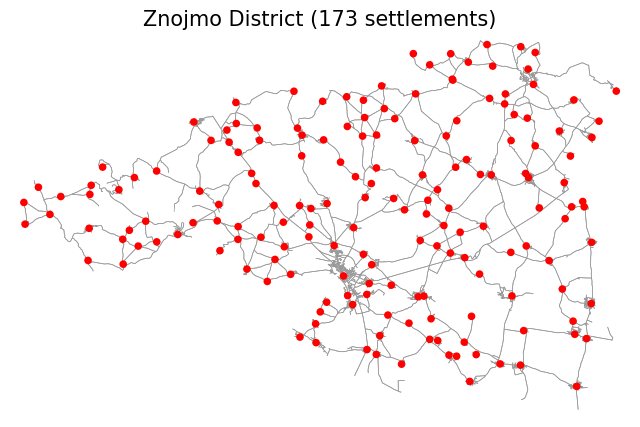

In [8]:
# VISUALIZATION
# Creating a list "settlement_nodes" from data
sidla_uzly = []
for node, data in G.nodes(data=True):
    if 'nazev_sidla' in data: # If the node has an assigned settlement name
        sidla_uzly.append(node)

print(f"Prepared {len(sidla_uzly)} settlements for visualization.")

# Set colors: RED for settlements, nothing (invisible) for other intersections
node_colors = []
node_sizes = []

for node in G.nodes():
    if node in sidla_uzly:
        node_colors.append('red') #  Settlement
        node_sizes.append(30)     # Point size
    else:
        node_colors.append('black')
        node_sizes.append(0)      # Size 0 = invisible node

# Draw the graph using OSMnx
# Using 'G' because it is the original graph from OSMnx with GPS coordinates
fig, ax = ox.plot_graph(G,
                        node_color=node_colors,
                        node_size=node_sizes,
                        edge_color='#999999', # light gray roads
                        edge_linewidth=0.5,
                        bgcolor='white',
                        show=False) # Do not display yet, we want to add a title

# Set title and display
ax.set_title(f"Znojmo District ({len(sidla_uzly)} settlements)", fontsize=15)
plt.show()

# Nejkratší Eulidovská vzdálenost

In [9]:
# Compute squared Euclidean distance between two points
def distance_squared(x1, y1, x2, y2):
    return (x2 - x1)**2 + (y2 - y1)**2

# A dictionary, where keys are coordinates and values are node IDs
def souradnice_na_id(body):
    slovnik = {}
    for i, b in enumerate(body):
        slovnik[b] = i
    return slovnik

# Create a graph represented as a dictionary
def hrany_do_grafu(slovnik_id, start_points, end_points, weights):
    graf = defaultdict(dict)
    for i in range(len(start_points)):
        u = slovnik_id[start_points[i]]
        v = slovnik_id[end_points[i]]
        w = weights[i]
        graf[u][v] = w
        graf[v][u] = w
    return graf

# Dijkstra algoritm
def dijkstra(graf, start, end):
    vzdalenosti = {uzel: float('inf') for uzel in graf}
    vzdalenosti[start] = 0
    predchudci = {uzel: None for uzel in graf}

    fronta = PriorityQueue()
    fronta.put((0, start))

    while not fronta.empty():
        aktualni_vzd, uzel = fronta.get()

        if uzel == end:
            break

        if aktualni_vzd > vzdalenosti[uzel]:
            continue

        for soused, w in graf[uzel].items():
            nova_vzd = vzdalenosti[uzel] + w
            if nova_vzd < vzdalenosti[soused]:
                vzdalenosti[soused] = nova_vzd
                predchudci[soused] = uzel
                fronta.put((nova_vzd, soused))

    cesta = []
    u = end
    while u is not None:
        cesta.append(u)
        u = predchudci[u]
    cesta.reverse()
    return cesta, vzdalenosti[end]

soubor = "graph.txt"

# Nejmenší transportní čas

# WITHOUT CURVATURE

In [10]:
def calculate_edge_speed(highway_type):
    # Estimate average speed for different road types (in km/h)
    # These are rough assumptions
    if highway_type in ['motorway', 'trunk', 'primary']:
        return 90 # km/h
    elif highway_type in ['secondary', 'tertiary']:
        return 70 # km/h
    elif highway_type in ['residential', 'unclassified', 'living_street']:
        return 30 # km/h
    else:
        return 50 # Default speed for other road types

# Compute real distance between two GPS points
def calculate_geodesic_distance(lat1, lon1, lat2, lon2):
    coords_1 = (lat1, lon1)
    coords_2 = (lat2, lon2)
    return geopy.distance.geodesic(coords_1, coords_2).meters

# Create a graph where edge weights represent travel time
def create_time_graph(G_osm, nodes, edges, consider_curvature=False):
    G_time = G_osm.copy()     # Copy the original OSM graph

     # Add travel time to each edge
    for u, v, k, data in G_time.edges(keys=True, data=True):
        length_m = data.get('length', 0) # road length in meters
        if length_m == 0:
            data['travel_time'] = float('inf')
            continue

        # Get road type for speed calculation
        highway_type = data.get('highway', 'unclassified')
        if isinstance(highway_type, list):
            highway_type = highway_type[0] # Take the first if multiple types

        speed_kmh = calculate_edge_speed(highway_type)
        speed_mps = speed_kmh / 3.6 # Convert km/h to m/s

        if speed_mps == 0:
            data['travel_time'] = float('inf')
            continue

        # Basic travel time (straight road assumption)
        time_sec = length_m / speed_mps

        if consider_curvature:
           # Use real GPS distance instead of straight-line length
            u_lat, u_lon = nodes.loc[u]['y'], nodes.loc[u]['x']
            v_lat, v_lon = nodes.loc[v]['y'], nodes.loc[v]['x']

            s_uv = calculate_geodesic_distance(u_lat, u_lon, v_lat, v_lon)


            if s_uv == 0: # Avoid division by zero for curvature
                kappa = 1 # No curvature if start and end points are the same
            else:
                kappa = length_m / s_uv

            # Apply curvature: t(u,v) = κ * (l(u,v) / v(u,v))
            time_sec = kappa * (length_m / speed_mps)

        data['travel_time'] = time_sec

    return G_time

In [11]:
def dijkstra_nx(G, start_node, end_node, weight='travel_time'):
    try:
        # Use NetworkX's built-in Dijkstra's algorithm
        path = nx.shortest_path(G, source=start_node, target=end_node, weight=weight)
           # Compute total cost (sum of weights along the path)
        total_weight = nx.shortest_path_length(G, source=start_node, target=end_node, weight=weight)
        # Return both the path (list of nodes) and its total cost

        if len(path) > 20:
          return path, total_weight
        else:
          return dijkstra_nx(G, start_node, end_node, weight='travel_time')

    except nx.NetworkXNoPath:
       # No connection exists between the two nodes
        print(f"No path found between {start_node} and {end_node}")
        return None, float('inf')
          # Any unexpected error
    except Exception as e:
        print(f"An error occurred: {e}")
        return None, float('inf')

In [12]:
G_time_no_curvature = create_time_graph(G, G.nodes, G.edges, consider_curvature=False)
print("Time-weighted graph without curvature created.")

Time-weighted graph without curvature created.


Selected Path 1: Start Node ID: 3671799125, End Node ID: 74309553
Selected Path 2: Start Node ID: 1112451726, End Node ID: 1366654736

Path 1 (No Curvature) - Total Travel Time: 558.06 seconds
Path 2 (No Curvature) - Total Travel Time: 1694.30 seconds
Visualizing Path 1 (No Curvature)...


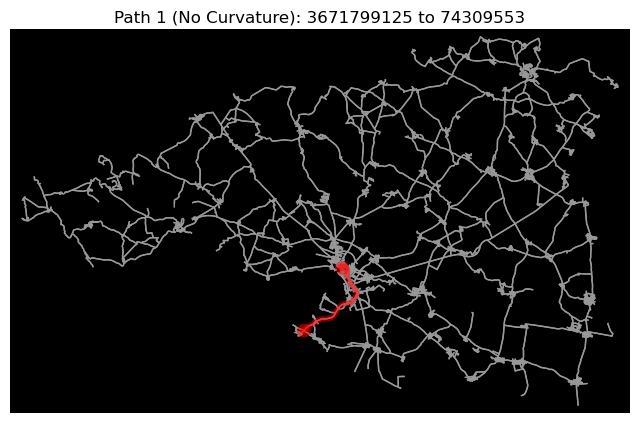

Visualizing Path 2 (No Curvature)...


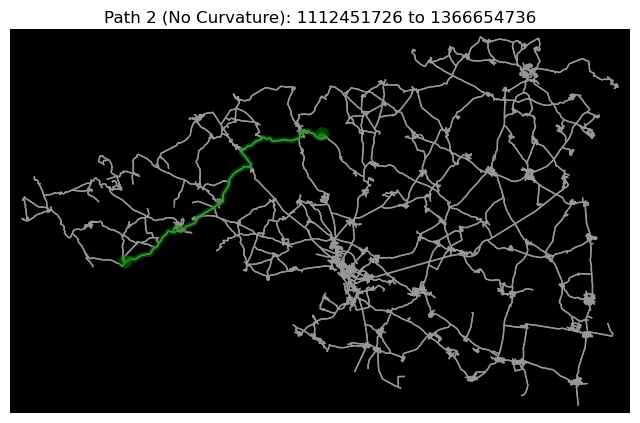

In [13]:
# Get all node from the graph
all_node_ids = list(G.nodes)

# Keep only nodes that are connected to at least one edge
# This avoids isolated nodes where no path exists
valid_nodes = [node for node in all_node_ids if G_time_no_curvature.degree(node) > 0]


# Path 1
# Pick a random start node
start_node_1 = random.choice(valid_nodes)
# Pick a random end node
end_node_1 = random.choice(valid_nodes)
# Make sure start and end are not the same
while start_node_1 == end_node_1:
    end_node_1 = random.choice(valid_nodes)

# Path 2
start_node_2 = random.choice(valid_nodes)
end_node_2 = random.choice(valid_nodes)
# Make sure this path is different from Path 1
# Start and end nodes must not be the same as before
while start_node_2 == end_node_2 or (start_node_2 == start_node_1 and end_node_2 == end_node_1):
    start_node_2 = random.choice(valid_nodes)
    end_node_2 = random.choice(valid_nodes)

# Print selected nodes for both paths
print(f"Selected Path 1: Start Node ID: {start_node_1}, End Node ID: {end_node_1}")
print(f"Selected Path 2: Start Node ID: {start_node_2}, End Node ID: {end_node_2}")

# SHORTEST PATH COMPUTATION

# Apply Dijkstra's algorithm for Path 1
path_1_no_curvature, time_1_no_curvature = dijkstra_nx(G_time_no_curvature, start_node_1, end_node_1)

# Apply Dijkstra's algorithm for Path 2
path_2_no_curvature, time_2_no_curvature = dijkstra_nx(G_time_no_curvature, start_node_2, end_node_2)


print(f"\nPath 1 (No Curvature) - Total Travel Time: {time_1_no_curvature:.2f} seconds")
print(f"Path 2 (No Curvature) - Total Travel Time: {time_2_no_curvature:.2f} seconds")

# Visualize the first path
if path_1_no_curvature:
    print("Visualizing Path 1 (No Curvature)...")
    fig, ax = ox.plot_graph_route(G, path_1_no_curvature, route_color='red', route_linewidth=4, node_size=0, bgcolor='k', show=False, close=False)
    ax.set_title(f'Path 1 (No Curvature): {start_node_1} to {end_node_1}')
    plt.show()
else:  # No path found
    print(f"Cannot visualize Path 1, no path found between {start_node_1} and {end_node_1}")

# Visualize the second path
if path_2_no_curvature:
    print("Visualizing Path 2 (No Curvature)...")
    fig, ax = ox.plot_graph_route(G, path_2_no_curvature, route_color='green', route_linewidth=4, node_size=0, bgcolor='k', show=False, close=False)
    ax.set_title(f'Path 2 (No Curvature): {start_node_2} to {end_node_2}')
    plt.show()
else:   # No path found
    print(f"Cannot visualize Path 2, no path found between {start_node_2} and {end_node_2}")

# WITH CURVATURE

In [14]:
# Convert the graph to GeoDataFrames
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G, nodes=True, edges=True)

# Create a new graph where edge weights are travel times
# (real GPS distance instead of straight-line length)
G_time_with_curvature = create_time_graph(
    G,  # original road graph
    nodes_gdf,
    edges_gdf,
    consider_curvature=True
)


Path 1 (With Curvature) - Total Travel Time: 569.04 seconds
Path 2 (With Curvature) - Total Travel Time: 1874.19 seconds
Visualizing Path 1 (With Curvature)...


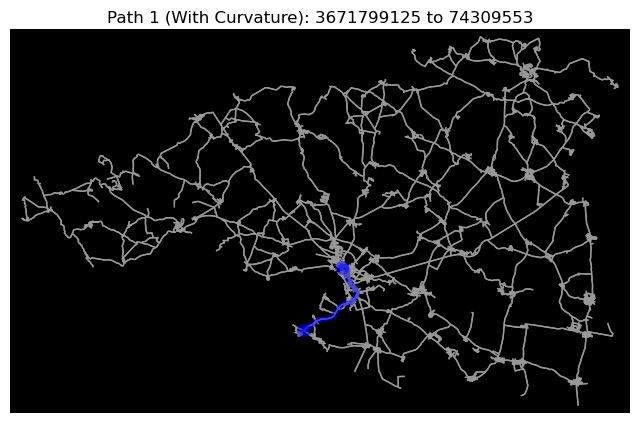

Visualizing Path 2 (With Curvature)...


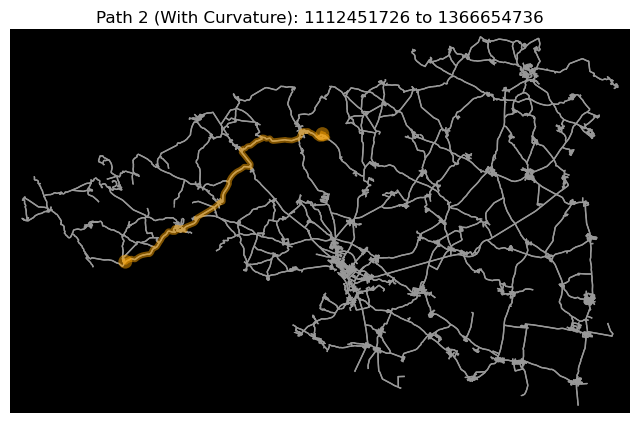

In [15]:
# Apply Dijkstra's algorithm for Path 1 (with curvature)
path_1_with_curvature, time_1_with_curvature = dijkstra_nx(G_time_with_curvature, start_node_1, end_node_1)

# Apply Dijkstra's algorithm for Path 2 (with curvature)
path_2_with_curvature, time_2_with_curvature = dijkstra_nx(G_time_with_curvature, start_node_2, end_node_2)

print(f"\nPath 1 (With Curvature) - Total Travel Time: {time_1_with_curvature:.2f} seconds")
print(f"Path 2 (With Curvature) - Total Travel Time: {time_2_with_curvature:.2f} seconds")
# Visualize the first path
if path_1_with_curvature:
    print("Visualizing Path 1 (With Curvature)...")
    fig, ax = ox.plot_graph_route(G, path_1_with_curvature, route_color='blue', route_linewidth=4, node_size=0, bgcolor='k', show=False, close=False)
    ax.set_title(f'Path 1 (With Curvature): {start_node_1} to {end_node_1}')
    plt.show()
else:
    print(f"Cannot visualize Path 1, no path found between {start_node_1} and {end_node_1}")

# Visualize the second path
if path_2_with_curvature:
    print("Visualizing Path 2 (With Curvature)...")
    fig, ax = ox.plot_graph_route(G, path_2_with_curvature, route_color='orange', route_linewidth=4, node_size=0, bgcolor='k', show=False, close=False)
    ax.set_title(f'Path 2 (With Curvature): {start_node_2} to {end_node_2}')
    plt.show()
else:
    print(f"Cannot visualize Path 2, no path found between {start_node_2} and {end_node_2}")


In [16]:
summary_data = []

# Path 1 results
summary_data.append({
    'Path ID': 1,
    'Start Node': start_node_1,
    'End Node': end_node_1,
    'Nodes (No Curv)': len(path_1_no_curvature) if path_1_no_curvature else 0,
    'Time (s) No Curv': f"{time_1_no_curvature:.2f}",
    'Nodes (With Curv)': len(path_1_with_curvature) if path_1_with_curvature else 0,
    'Time (s) With Curv': f"{time_1_with_curvature:.2f}"
})

# Path 2 results
summary_data.append({
    'Path ID': 2,
    'Start Node': start_node_2,
    'End Node': end_node_2,
    'Nodes (No Curv)': len(path_2_no_curvature) if path_2_no_curvature else 0,
    'Time (s) No Curv': f"{time_2_no_curvature:.2f}",
    'Nodes (With Curv)': len(path_2_with_curvature) if path_2_with_curvature else 0,
    'Time (s) With Curv': f"{time_2_with_curvature:.2f}"
})

summary_df = pd.DataFrame(summary_data)
print("Summary Table:")
print(summary_df.to_markdown(index=False))


Summary Table:
|   Path ID |   Start Node |   End Node |   Nodes (No Curv) |   Time (s) No Curv |   Nodes (With Curv) |   Time (s) With Curv |
|----------:|-------------:|-----------:|------------------:|-------------------:|--------------------:|---------------------:|
|         1 |   3671799125 |   74309553 |                66 |             558.06 |                  66 |               569.04 |
|         2 |   1112451726 | 1366654736 |                52 |            1694.3  |                  60 |              1874.19 |


# *Návrh jiného ohodnocennı hran zohlednující křivolakost silničí sítě - umocnění*


In [17]:
def create_time_graph(G_osm, nodes, edges, consider_curvature=False):
    G_time = G_osm.copy()

    # Add speed and time attributes to edges
    for u, v, k, data in G_time.edges(keys=True, data=True):
        length_m = data.get('length', 0) # length in meters
        if length_m == 0:
            data['travel_time'] = float('inf')
            continue

        # Get road type for speed calculation
        highway_type = data.get('highway', 'unclassified')
        if isinstance(highway_type, list):
            highway_type = highway_type[0] # Take the first if multiple types

        speed_kmh = calculate_edge_speed(highway_type)
        speed_mps = speed_kmh / 3.6 # Convert km/h to m/s

        if speed_mps == 0:
            data['travel_time'] = float('inf')
            continue

        # Time without curvature: t = l / v
        time_sec = length_m / speed_mps

        if consider_curvature:
            # Get coordinates for geodesic distance
            u_lat, u_lon = nodes.loc[u]['y'], nodes.loc[u]['x']
            v_lat, v_lon = nodes.loc[v]['y'], nodes.loc[v]['x']

            s_uv = calculate_geodesic_distance(u_lat, u_lon, v_lat, v_lon)

            if s_uv == 0: # Avoid division by zero for curvature
                kappa = 1 # No curvature if start and end points are the same
            else:
                kappa = (length_m / s_uv)**2 # Implementing κ_new = (l(u,v) / s(u,v))^2

            # Apply curvature: t(u,v) = κ * (l(u,v) / v(u,v))
            time_sec = kappa * (length_m / speed_mps)

        data['travel_time'] = time_sec

    return G_time


In [18]:
# Convert the graph to GeoDataFrames
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G, nodes=True, edges=True)

G_time_new_curvature = create_time_graph(
    G,
    nodes_gdf,
    edges_gdf,
    consider_curvature=True
)


Path 1 (With New Curvature) - Total Travel Time: 580.56 seconds
Path 2 (With New Curvature) - Total Travel Time: 2093.32 seconds
Visualizing Path 1 (With New Curvature)...


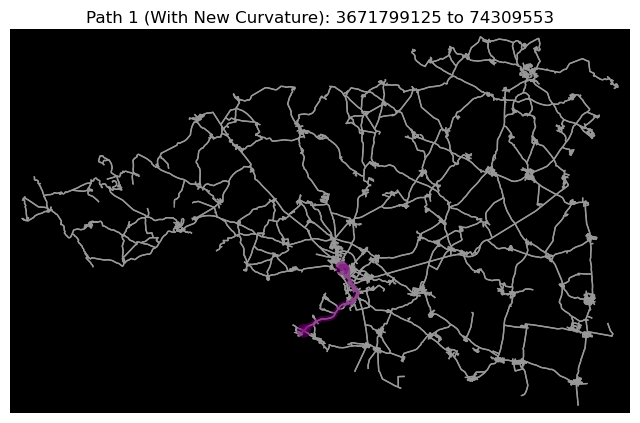

Visualizing Path 2 (With New Curvature)...


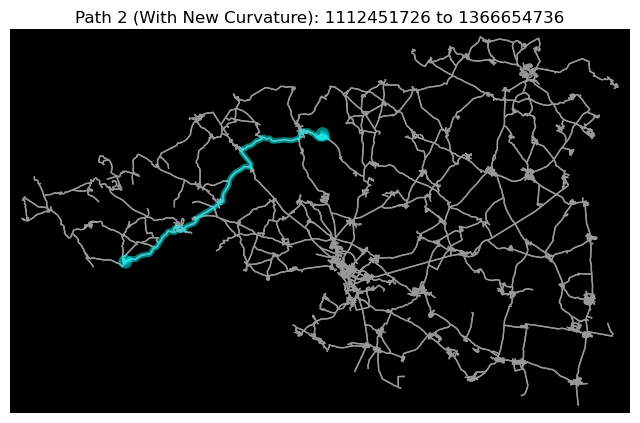

In [19]:
# Apply Dijkstra's algorithm for Path 1 (with new curvature)
path_1_new_curvature, time_1_new_curvature = dijkstra_nx(G_time_new_curvature, start_node_1, end_node_1)

# Apply Dijkstra's algorithm for Path 2 (with new curvature)
path_2_new_curvature, time_2_new_curvature = dijkstra_nx(G_time_new_curvature, start_node_2, end_node_2)

print(f"\nPath 1 (With New Curvature) - Total Travel Time: {time_1_new_curvature:.2f} seconds")
print(f"Path 2 (With New Curvature) - Total Travel Time: {time_2_new_curvature:.2f} seconds")


# Visualize the first path with new curvature
if path_1_new_curvature:
    print("Visualizing Path 1 (With New Curvature)...")
    fig, ax = ox.plot_graph_route(G, path_1_new_curvature, route_color='purple', route_linewidth=4, node_size=0, bgcolor='k', show=False, close=False)
    ax.set_title(f'Path 1 (With New Curvature): {start_node_1} to {end_node_1}')
    plt.show()
else:
    print(f"Cannot visualize Path 1, no path found between {start_node_1} and {end_node_1}")

# Visualize the second path with new curvature
if path_2_new_curvature:
    print("Visualizing Path 2 (With New Curvature)...")
    fig, ax = ox.plot_graph_route(G, path_2_new_curvature, route_color='cyan', route_linewidth=4, node_size=0, bgcolor='k', show=False, close=False)
    ax.set_title(f'Path 2 (With New Curvature): {start_node_2} to {end_node_2}')
    plt.show()
else:
    print(f"Cannot visualize Path 2, no path found between {start_node_2} and {end_node_2}")


In [20]:
summary_data = []

# Path 1 results
summary_data.append({
    'Path ID': 1,
    'Start Node': start_node_1,
    'End Node': end_node_1,
    'Nodes (No Curv)': len(path_1_no_curvature) if path_1_no_curvature else 0,
    'Time (s) No Curv': f"{time_1_no_curvature:.2f}",
    'Nodes (Curv)': len(path_1_with_curvature) if path_1_with_curvature else 0,
    'Time (s) Curv': f"{time_1_with_curvature:.2f}",
    'Nodes (New Curv)': len(path_1_new_curvature) if path_1_new_curvature else 0,
    'Time (s) New Curv': f"{time_1_new_curvature:.2f}"
})

# Path 2 results
summary_data.append({
    'Path ID': 2,
    'Start Node': start_node_2,
    'End Node': end_node_2,
    'Nodes (No Curv)': len(path_2_no_curvature) if path_2_no_curvature else 0,
    'Time (s) No Curv': f"{time_2_no_curvature:.2f}",
    'Nodes (Curv)': len(path_2_with_curvature) if path_2_with_curvature else 0,
    'Time (s) Curv': f"{time_2_with_curvature:.2f}",
    'Nodes (New Curv)': len(path_2_new_curvature) if path_2_new_curvature else 0,
    'Time (s) New Curv': f"{time_2_new_curvature:.2f}"
})

summary_df = pd.DataFrame(summary_data)
print("Summary Table:")
print(summary_df.to_markdown(index=False))

Summary Table:
|   Path ID |   Start Node |   End Node |   Nodes (No Curv) |   Time (s) No Curv |   Nodes (Curv) |   Time (s) Curv |   Nodes (New Curv) |   Time (s) New Curv |
|----------:|-------------:|-----------:|------------------:|-------------------:|---------------:|----------------:|-------------------:|--------------------:|
|         1 |   3671799125 |   74309553 |                66 |             558.06 |             66 |          569.04 |                 66 |              580.56 |
|         2 |   1112451726 | 1366654736 |                52 |            1694.3  |             60 |         1874.19 |                 60 |             2093.32 |


# Borůvka

In [22]:
def init_komponenty(n):
    komp = {}
    for i in range(n):
        komp[i] = i
    return komp

def najdi(u, komp):
    return komp[u]

def spoj(c1, c2, komp):
    for k in komp:
        if komp[k] == c2:
            komp[k] = c1

def boruvka(graf):
    mst = []
    komp = init_komponenty(len(graf))
    zmena = True

    while zmena:
        zmena = False
        nejlevnejsi = {}

        for u in graf:
            for v in graf[u]:
                w = graf[u][v]
                cu = najdi(u, komp)
                cv = najdi(v, komp)

                if cu != cv:
                    if cu not in nejlevnejsi or nejlevnejsi[cu][2] > w:
                        nejlevnejsi[cu] = (u, v, w)
                    if cv not in nejlevnejsi or nejlevnejsi[cv][2] > w:
                        nejlevnejsi[cv] = (u, v, w)

        for c in nejlevnejsi:
            u, v, w = nejlevnejsi[c]
            cu = najdi(u, komp)
            cv = najdi(v, komp)

            if cu != cv:
                mst.append((u, v, w))
                spoj(cu, cv, komp)
                zmena = True

    return mst


soubor = "graph.txt"

start, end, weights = load_edges(soubor)

vsechny_body = start + end
unikatni_body = list(set(vsechny_body))

slovnik_id = souradnice_na_id(unikatni_body)
graf = hrany_do_grafu(slovnik_id, start, end, weights)

mst = boruvka(graf)

suma = 0
for u, v, w in mst:
    suma += w

print("Number od edges in MST:", len(mst))
print("Whole lenght (Eukleid):", suma)

Number od edges in MST: 5735
Whole lenght (Eukleid): 929152.6538033165


# Digitální model terénu

In [23]:

def create_time_graph(G_osm, nodes, edges, consider_curvature=False, consider_dtm=False):
    G_time = G_osm.copy()

    # Add speed and time attributes to edges
    for u, v, k, data in G_time.edges(keys=True, data=True):
        length_m = data.get('length', 0) # length in meters
        if length_m == 0:
            data['travel_time'] = float('inf')
            continue

        # Get highway type for speed calculation
        highway_type = data.get('highway', 'unclassified')
        if isinstance(highway_type, list):
            highway_type = highway_type[0] # Take the first if multiple types

        speed_kmh = calculate_edge_speed(highway_type)
        speed_mps = speed_kmh / 3.6 # Convert km/h to m/s

        if speed_mps == 0:
            data['travel_time'] = float('inf')
            continue


# DTM Integration
        if consider_dtm:
            u_elevation = nodes.loc[u].get('elevation', 0) # Default to 0 if elevation missing
            v_elevation = nodes.loc[v].get('elevation', 0) # Default to 0 if elevation missing

            delta_elevation = v_elevation - u_elevation

            if length_m > 0:
                slope = delta_elevation / length_m
            else:
                slope = 0 # No slope if no length

            # Adjust speed based on slope
            # These factors are illustrative and can be tuned
            if slope > 0.05:  # Uphill
                speed_mps *= 0.7 # Decrease speed by 30%
            elif slope > 0.01: # Moderate uphill
                speed_mps *= 0.9 # Decrease speed by 10%
            elif slope < -0.05: # Downhill
                speed_mps *= 1.3 # Increase speed by 30%
            elif slope < -0.01: # Moderate downhill
                speed_mps *= 1.1 # Increase speed by 10%

            # Ensure speed remains within reasonable bounds (e.g., 5 m/s to 40 m/s)
            speed_mps = builtins.max(5.0, builtins.min(speed_mps, 40.0))

            if speed_mps == 0:
                data['travel_time'] = float('inf')
                continue
        # --- End DTM Integration ---

        # Time without curvature: t = l / v (using potentially adjusted speed_mps)
        time_sec = length_m / speed_mps

        if consider_curvature:
            # Get coordinates for geodesic distance
            u_lat, u_lon = nodes.loc[u]['y'], nodes.loc[u]['x']
            v_lat, v_lon = nodes.loc[v]['y'], nodes.loc[v]['x']

            s_uv = calculate_geodesic_distance(u_lat, u_lon, v_lat, v_lon)

            if s_uv == 0: # Avoid division by zero for curvature
                kappa = 1 # No curvature if start and end points are the same
            else:
                kappa = (length_m / s_uv)**2 # Implementing κ_new = (l(u,v) / s(u,v))^2

            # Apply curvature: t(u,v) = κ * (l(u,v) / v(u,v))
            time_sec = kappa * (length_m / speed_mps) # Using potentially adjusted speed_mps

        data['travel_time'] = time_sec

    return G_time

print("Modified create_time_graph function to include DTM consideration and fixed min/max usage.")



Modified create_time_graph function to include DTM consideration and fixed min/max usage.


Time-weighted graph with DTM and curvature created.

Path 1 (With DTM) - Total Travel Time: 595.90 seconds
Path 2 (With DTM) - Total Travel Time: 2049.83 seconds
Visualizing Path 1 (With DTM)...


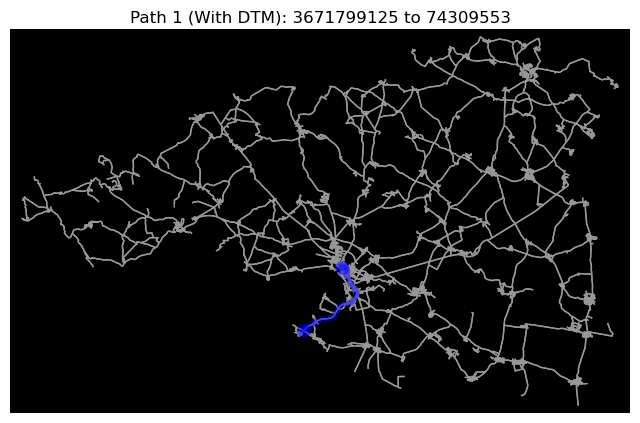

Visualizing Path 2 (With DTM)...


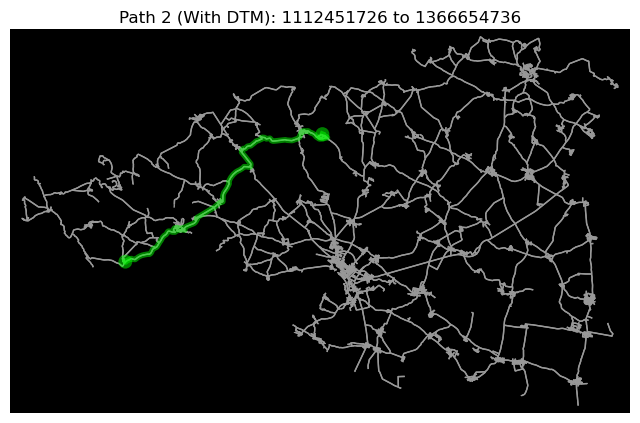

In [24]:
# Create time-weigted graph G_time_with_dtm
G_time_with_dtm = create_time_graph(G, nodes, edges, consider_curvature=True, consider_dtm=True)
print("Time-weighted graph with DTM and curvature created.")

# Compute the shortest path for path_1 with DTM
path_1_with_dtm, time_1_with_dtm = dijkstra_nx(G_time_with_dtm, start_node_1, end_node_1)

# Compute the shortest path for path_2 with DTM
path_2_with_dtm, time_2_with_dtm = dijkstra_nx(G_time_with_dtm, start_node_2, end_node_2)

# Print total travel times for both paths with DTM
print(f"\nPath 1 (With DTM) - Total Travel Time: {time_1_with_dtm:.2f} seconds")
print(f"Path 2 (With DTM) - Total Travel Time: {time_2_with_dtm:.2f} seconds")

# Visualize path_1_with_dtm
if path_1_with_dtm:
    print("Visualizing Path 1 (With DTM)...")
    fig, ax = ox.plot_graph_route(G, path_1_with_dtm, route_color='blue', route_linewidth=4, node_size=0, bgcolor='k', show=False, close=False)
    ax.set_title(f'Path 1 (With DTM): {start_node_1} to {end_node_1}')
    plt.show()
else:
    print(f"Cannot visualize Path 1, no path found between {start_node_1} and {end_node_1}")

# Visualize path_2_with_dtm
if path_2_with_dtm:
    print("Visualizing Path 2 (With DTM)...")
    fig, ax = ox.plot_graph_route(G, path_2_with_dtm, route_color='lime', route_linewidth=4, node_size=0, bgcolor='k', show=False, close=False)
    ax.set_title(f'Path 2 (With DTM): {start_node_2} to {end_node_2}')
    plt.show()
else:
    print(f"Cannot visualize Path 2, no path found between {start_node_2} and {end_node_2}")


In [25]:
summary_data = []

# Path 1 results
summary_data.append({
    'Path ID': 1,
    'Start Node': start_node_1,
    'End Node': end_node_1,
    'Nodes (No Curv)': len(path_1_no_curvature) if path_1_no_curvature else 0,
    'Time (s) No Curv': f"{time_1_no_curvature:.2f}",
    'Nodes (Curv)': len(path_1_with_curvature) if path_1_with_curvature else 0,
    'Time (s) Curv': f"{time_1_with_curvature:.2f}",
    'Nodes (New Curv)': len(path_1_new_curvature) if path_1_new_curvature else 0,
    'Time (s) New Curv': f"{time_1_new_curvature:.2f}",
    'Nodes (DTM)': len(path_1_with_dtm) if path_1_with_dtm else 0,
    'Time (s) DTM': f"{time_1_with_dtm:.2f}"
})

# Path 2 results
summary_data.append({
    'Path ID': 2,
    'Start Node': start_node_2,
    'End Node': end_node_2,
    'Nodes (No Curv)': len(path_2_no_curvature) if path_2_no_curvature else 0,
    'Time (s) No Curv': f"{time_2_no_curvature:.2f}",
    'Nodes (Curv)': len(path_2_with_curvature) if path_2_with_curvature else 0,
    'Time (s) Curv': f"{time_2_with_curvature:.2f}",
    'Nodes (New Curv)': len(path_2_new_curvature) if path_2_new_curvature else 0,
    'Time (s) New Curv': f"{time_2_new_curvature:.2f}",
    'Nodes (DTM)': len(path_2_with_dtm) if path_2_with_dtm else 0,
    'Time (s) DTM': f"{time_2_with_dtm:.2f}"
})

summary_df = pd.DataFrame(summary_data)
print("Summary Table:")
print(summary_df.to_markdown(index=False))


Summary Table:
|   Path ID |   Start Node |   End Node |   Nodes (No Curv) |   Time (s) No Curv |   Nodes (Curv) |   Time (s) Curv |   Nodes (New Curv) |   Time (s) New Curv |   Nodes (DTM) |   Time (s) DTM |
|----------:|-------------:|-----------:|------------------:|-------------------:|---------------:|----------------:|-------------------:|--------------------:|--------------:|---------------:|
|         1 |   3671799125 |   74309553 |                66 |             558.06 |             66 |          569.04 |                 66 |              580.56 |            66 |         595.9  |
|         2 |   1112451726 | 1366654736 |                52 |            1694.3  |             60 |         1874.19 |                 60 |             2093.32 |            60 |        2049.83 |
